In [35]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import norm
import matplotlib.pyplot as plt
import re
import math

In [2]:
def prepare_subset(data, LOD, logit_transform, subset_type=1, random_state=42):
    """
    subset_type:
        1 → closest-to-0.5 selection (current behavior)
        2 → random sampling within each group
    """

    base = data.copy()

    if subset_type == 1:
        subset = (
            base
            .assign(dist=lambda x: (x["DPS1 Frequency"] - 0.5).abs())
            .loc[lambda x: x.groupby(
                ["Individual ID", "DPS1", "DPS2"]
            )["dist"].idxmin()]
            .drop(columns="dist")
            .reset_index(drop=True)
        )

    elif subset_type == 2:
        subset = (
            base
            .groupby(["Individual ID", "DPS1", "DPS2"], group_keys=False)
            .sample(n=1, random_state=random_state)
            .reset_index(drop=True)
        )

    else:
        raise ValueError("subset_type must be 1 or 2")

    return subset

In [3]:
def bm_loglik_sigma_x_censored_varyingT(
    X0, XT, T_arr, sigma_x,
    f_threshold=0.02, x_threshold=None
):
    """
    Sum loglik across observations with per-observation T.
    X0, XT are in X-space already (logit frequencies).
    """
    X0 = np.asarray(X0, float)
    XT = np.asarray(XT, float)
    T_arr = np.asarray(T_arr, float)

    if not (len(X0) == len(XT) == len(T_arr)):
        raise ValueError("X0, XT, T_arr must have the same length.")
    if np.any(T_arr <= 0):
        raise ValueError("All T must be > 0.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    # threshold in X-space
    if x_threshold is None:
        x_threshold = float(logit_transform(f_threshold))

    ll = 0.0
    for x0, xt, T in zip(X0, XT, T_arr):
        # call your existing function on a single row by making shape (1,2)
        ll += bm_loglik_sigma_x_censored(
            X_pairs=np.array([[x0, xt]]),
            T=float(T),
            sigma_x=float(sigma_x),
            f_threshold=f_threshold,
            x_threshold=x_threshold
        )
    return float(ll)

from scipy.special import log_ndtr

from scipy.special import log_ndtr

def bm_loglik_sigma_x_censored_varyingT_freqspace(
    X0, XT, T_arr, sigma_x,
    f_lower=0.02, f_upper=0.98,
    x_lower=None, x_upper=None,
):
    """
    Frequency-space likelihood for Brownian motion in X = logit(f),
    with interval censoring at BOTH ends of the frequency scale.

        fT <  f_lower  ->  log P(X_T <  x_lower | X_0)
        fT >  f_upper  ->  log P(X_T >  x_upper | X_0)
        otherwise      ->  log p_X(X_T | X_0) + log |dX/df_T|

    Set f_upper=None to disable upper censoring.
    """
    X0 = np.asarray(X0, float)
    XT = np.asarray(XT, float)
    T_arr = np.asarray(T_arr, float)

    if not (len(X0) == len(XT) == len(T_arr)):
        raise ValueError("X0, XT, T_arr must have the same length.")
    if np.any(T_arr <= 0):
        raise ValueError("All T must be > 0.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_lower is None:
        x_lower = float(logit_transform(f_lower))
    if x_upper is None and f_upper is not None:
        x_upper = float(logit_transform(f_upper))
    if x_upper is not None and x_upper <= x_lower:
        raise ValueError("upper threshold must exceed lower threshold.")

    sd = sigma_x * np.sqrt(T_arr)

    # strict comparisons on both ends, matching the spectral implementation
    is_lower = XT < x_lower
    is_upper = (np.zeros_like(is_lower) if x_upper is None
                else XT > x_upper)
    is_exact = ~(is_lower | is_upper)

    ll = 0.0

    if np.any(is_exact):
        z = (XT[is_exact] - X0[is_exact]) / sd[is_exact]
        log_density_X = (-0.5 * z**2
                         - np.log(sd[is_exact])
                         - 0.5 * np.log(2 * np.pi))
        fT_e = np.clip(1.0 / (1.0 + np.exp(-XT[is_exact])), 1e-12, 1 - 1e-12)
        log_jacobian = -np.log(fT_e) - np.log1p(-fT_e)
        ll += np.sum(log_density_X + log_jacobian)

    if np.any(is_lower):
        ll += np.sum(log_ndtr((x_lower - X0[is_lower]) / sd[is_lower]))

    if np.any(is_upper):
        ll += np.sum(log_ndtr((X0[is_upper] - x_upper) / sd[is_upper]))

    return float(ll)

def compute_sigma_profile(df2, sigma_grid, f_lower=0.02, f_upper=0.98):
    chi2_95_df1 = 3.841458820694124
    cut = -0.5 * chi2_95_df1

    ll_grid = np.array([
        bm_loglik_sigma_x_censored_varyingT_freqspace(
            X0=df2["X0"].to_numpy(),
            XT=df2["XT"].to_numpy(),
            T_arr=df2["T"].to_numpy(),
            sigma_x=s,
            f_lower=f_lower,
            f_upper=f_upper,
        )
        for s in sigma_grid
    ], dtype=float)

    mle_idx = int(np.argmax(ll_grid))
    sigma_mle = float(sigma_grid[mle_idx])
    ll_mle = float(ll_grid[mle_idx])
    ll_centered = ll_grid - ll_mle

    i_hat = mle_idx

    # left CI
    left_idx_candidates = np.where(ll_centered[:i_hat + 1] < cut)[0]
    if len(left_idx_candidates) == 0:
        ci_low = float(sigma_grid[0])
    else:
        i1 = int(left_idx_candidates[-1])
        i2 = min(i1 + 1, i_hat)
        x1, x2 = float(sigma_grid[i1]), float(sigma_grid[i2])
        y1, y2 = float(ll_centered[i1]), float(ll_centered[i2])
        ci_low = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x1

    # right CI
    right_idx_candidates = np.where(ll_centered[i_hat:] < cut)[0]
    if len(right_idx_candidates) == 0:
        ci_high = float(sigma_grid[-1])
    else:
        j2 = int(i_hat + right_idx_candidates[0])
        j1 = max(j2 - 1, i_hat)
        x1, x2 = float(sigma_grid[j1]), float(sigma_grid[j2])
        y1, y2 = float(ll_centered[j1]), float(ll_centered[j2])
        ci_high = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x2

    return {
        "ll_grid": ll_grid,
        "ll_centered": ll_centered,
        "sigma_mle": sigma_mle,
        "ll_mle": ll_mle,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cut": cut,
    }

label_font = 15
tick_font = 11
panel_font = 13


def plot_segments(ax, df2, panel_label, xlabel="Days post symptom onset"):
    id_col = "Individual ID" if "Individual ID" in df2.columns else (
        "Individual" if "Individual" in df2.columns else None
    )

    if id_col is None:
        for _, row in df2.iterrows():
            ax.plot(
                [row["DPS1"], row["DPS2"]],
                [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                alpha=0.7
            )
    else:
        for _, group in df2.groupby(id_col):
            for _, row in group.iterrows():
                ax.plot(
                    [row["DPS1"], row["DPS2"]],
                    [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                    alpha=0.7
                )

    ax.set_xlabel(xlabel, fontsize=label_font)
    ax.axhline(LOD, linestyle=":", label="LOD", color="grey")
    ax.set_ylabel("iSNV frequency ($f_2$)", fontsize=label_font)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_ll_panel(ax, sigma_grid, prof, panel_label):
    ax.plot(sigma_grid, prof["ll_grid"])
    ax.axvline(
        prof["sigma_mle"],
        linestyle="-",
        label=rf"MLE $\hat{{\sigma}}_x$ = {prof['sigma_mle']:.3f}"
    )
    # ax.scatter([prof["sigma_mle"]], [0.0], zorder=3)
    # ax.axhline(prof["cut"], color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.axvspan(prof["ci_low"], prof["ci_high"], alpha=0.15)
    ax.axvline(
        prof["ci_low"],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=rf"95% CI = [{prof['ci_low']:.3f}, {prof['ci_high']:.3f}]"
    )
    ax.axvline(prof["ci_high"], color="gray", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\sigma_x$", fontsize=label_font)
    ax.set_ylabel("Log-likelihood", fontsize=label_font)
    ax.tick_params(axis="both", labelsize=tick_font)

    # ax.legend(frameon=False, fontsize=8, loc="lower right")

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_heatmap_panel(ax, fig, targets, panel_label,
                       eps_min=0.0, eps_max=5.0, n_eps=400,
                       rho_min=0.0, rho_max=1.0, n_rho=400):
    epsilon = np.linspace(eps_min, eps_max, n_eps)
    rho = np.linspace(rho_min, rho_max, n_rho)
    E, R = np.meshgrid(epsilon, rho)
    sigma = E * np.sqrt(2 * (1 - R))

    im = ax.imshow(
        sigma,
        origin="lower",
        aspect="auto",
        extent=[eps_min, eps_max, rho_min, rho_max]
    )

    cs = ax.contour(
        E, R, sigma,
        levels=sorted(targets),
        linewidths=2,
        colors="white",
        linestyles=["dashed", "solid", "dashed"]
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\sigma_x$', fontsize=label_font)
    cbar.ax.tick_params(labelsize=tick_font)

    ax.set_xlabel(r'$\epsilon$', fontsize=label_font)
    ax.set_ylabel(r'$\rho$', fontsize=label_font)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )

### IAV-Table_S1

In [4]:
mccrone = pd.read_csv("data/raw_data/table_S1.csv")
LOD = 0.02
dps_filter_mccrone = mccrone[(mccrone["DPS1 Frequency"] >= LOD)]
dps_filter_mccrone["Individual ID"].nunique()

28

In [5]:
Table_S1 = dps_filter_mccrone.rename(columns={
    "DPS1": "First sample (in days post symptom onset)",
    "DPS2": "Second sample (in days post symptom onset)",
    "DPS1 Frequency": "First sample iSNV frequency",
    "DPS2 Frequency": "Second sample iSNV frequency"
}).drop(columns=["Subset"])

In [24]:
Table_S1.to_csv("data/Table_S1.csv", index=False)

In [6]:
dps_filter_mccrone

,Individual ID,iSNV,DPS1,DPS2,DPS1 Frequency,DPS2 Frequency,Subset
1,50001,PA_G271A,0,6,0.091580,0.000000,NaN
2,50001,PB2_G1072A,0,6,0.096753,0.000000,1.0
8,50141,HA_C207A,1,2,0.023410,0.003021,NaN
10,50141,HA_A982G,1,2,0.024175,0.003213,1.0
11,50141,HA_G996A,1,2,0.020366,0.024453,NaN
12,50141,NS_A626G,1,2,0.021541,0.007928,NaN
13,50143,HA_T968G,1,2,0.118747,0.159688,1.0
14,50143,PA_G895A,1,2,0.045579,0.037244,NaN
15,50143,PB2_G1058A,1,2,0.035753,0.058976,NaN
16,50167,HA_T462C,1,4,0.289960,0.004924,1.0


#### Subset analysis 

In [7]:
LOD = 0.02
def logit_transform(f, eps=1e-12):
    f = np.clip(f, eps, 1 - eps)
    return np.log(f / (1.0 - f))

# --- Prepare the two datasets ---
df = dps_filter_mccrone.copy()
for col in ["DPS1", "DPS2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["X0"] = df["DPS1 Frequency"].map(logit_transform)
df["XT"] = df["DPS2 Frequency"].map(logit_transform)
df["T"] = (df["DPS2"] - df["DPS1"])
df = df.dropna(subset=["DPS1", "DPS2"]).copy()

# Full dataset
mccrone_f = df.copy()

# --- Subset 2 for all three rows ---
full_df2  = prepare_subset(mccrone_f, LOD, logit_transform, subset_type=2, random_state=43)
#full_df2.to_csv("mccrone_full_subset2.csv", index=False)
full_df1  = prepare_subset(mccrone_f, LOD, logit_transform, subset_type=1, random_state=46)
#full_df1.to_csv("mccrone_full_subset1.csv", index=False)


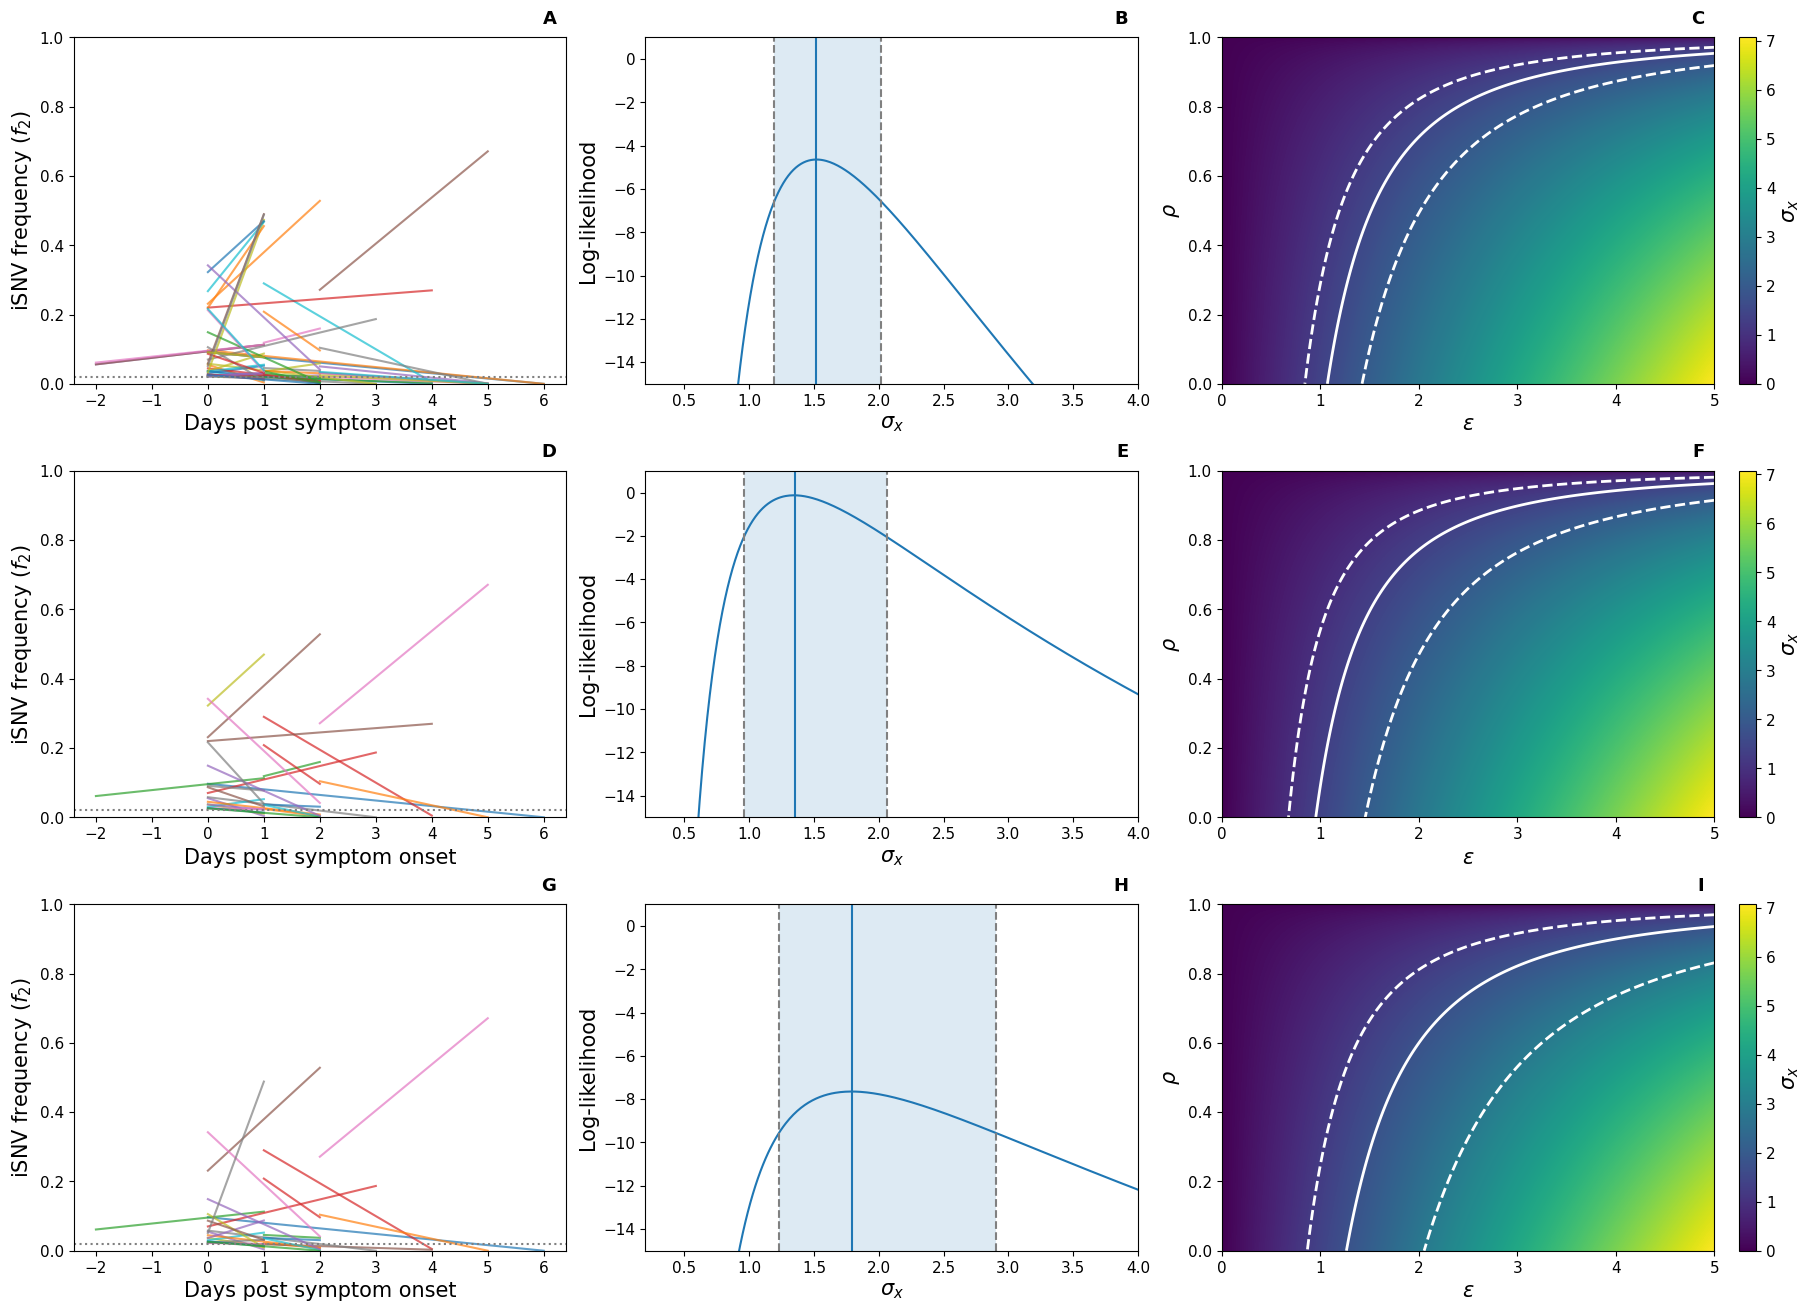

set_2
MLE sigma_x = 1.790977
Max log-likelihood = -7.647709
95% LR CI = [1.229195, 2.906588]

FULL
MLE sigma_x = 1.517293
Max log-likelihood = -4.639973
95% LR CI = [1.194854, 2.015369]

set_1
MLE sigma_x = 1.351128
Max log-likelihood = -0.129278
95% LR CI = [0.959936, 2.061294]


In [8]:
# --- Sigma grid and profiles ---
sigma_grid = np.linspace(0.1, 4, 400)

full  = compute_sigma_profile(mccrone_f, sigma_grid, f_lower=0.02, f_upper=0.98)
set_1 = compute_sigma_profile(full_df1, sigma_grid, f_lower=0.02, f_upper=0.98)
set_2  = compute_sigma_profile(full_df2, sigma_grid, f_lower=0.02, f_upper=0.98)

# --- Heatmap contour targets ---
# Replace full_targets with the values for the full dataset row
full_targets  = sorted([full["sigma_mle"], full["ci_high"], full["ci_low"]])
subset1_targets  = sorted([set_1["sigma_mle"], set_1["ci_high"], set_1["ci_low"]])
subset2_targets = sorted([set_2["sigma_mle"], set_2["ci_high"], set_2["ci_low"]])

# --- 3 x 3 figure ---
fig, axes = plt.subplots(3, 3, figsize=(18, 13), constrained_layout=True)

# Row 1: full
plot_segments(axes[0, 0], mccrone_f, "A", xlabel="Days post symptom onset")
plot_ll_panel(axes[0, 1], sigma_grid, full, "B")
plot_heatmap_panel(axes[0, 2], fig, full_targets, "C")

plot_segments(axes[1, 0], full_df1, "D", xlabel="Days post symptom onset")
plot_ll_panel(axes[1, 1], sigma_grid, set_1, "E")
plot_heatmap_panel(axes[1, 2], fig, subset1_targets, "F")

plot_segments(axes[2, 0], full_df2, "G", xlabel="Days post symptom onset")
plot_ll_panel(axes[2, 1], sigma_grid, set_2, "H")
plot_heatmap_panel(axes[2, 2], fig, subset2_targets, "I")

# Match likelihood axis ranges
for ax in [axes[0, 1], axes[1, 1], axes[2, 1]]:
    ax.set_xlim(0.2, 4)
    ax.set_ylim(-15, 1)

plt.show()

print("set_2")
print(f"MLE sigma_x = {set_2['sigma_mle']:.6f}")
print(f"Max log-likelihood = {set_2['ll_mle']:.6f}")
print(f"95% LR CI = [{set_2['ci_low']:.6f}, {set_2['ci_high']:.6f}]")

print("\nFULL")
print(f"MLE sigma_x = {full['sigma_mle']:.6f}")
print(f"Max log-likelihood = {full['ll_mle']:.6f}")
print(f"95% LR CI = [{full['ci_low']:.6f}, {full['ci_high']:.6f}]")

print("\nset_1")
print(f"MLE sigma_x = {set_1['sigma_mle']:.6f}")
print(f"Max log-likelihood = {set_1['ll_mle']:.6f}")
print(f"95% LR CI = [{set_1['ci_low']:.6f}, {set_1['ci_high']:.6f}]")


### SARS-CoV-2–Table_S2

In [9]:
df = pd.read_csv(
    "data/raw_data/elife-66857-supp2-v3.txt",
    sep="\t",
    dtype=str,         
    na_values=[".", "NA", ""],  
    keep_default_na=False       
)
sample_bio = pd.read_csv("data/raw_data/elife-66857-supp1-v3.csv")
sample_bio.dropna(subset=["biosample_sources"])

,sample_id,collection_date,received_date,adm2,biosample_sources,diagnostic_ct_value,n_samples
0,CAMB-7277D,2020-03-24,2020-03-24,CAMBRIDGESHIRE,CAMS000720,15.0,1
7,CAMB-76928,2020-03-29,2020-03-31,LONDON,CAMS001741,23.0,5
17,CAMB-77866,2020-03-31,2020-04-01,HERTFORDSHIRE,CAMS001997,16.0,2
26,CAMB-723B5,2020-03-24,2020-03-24,BEDFORDSHIRE,CAMS000436,27.0,1
30,CAMB-76937,2020-03-30,2020-03-31,LONDON,CAMS001741,19.0,5
...,...,...,...,...,...,...,...
1118,CAMB-78DC0,2020-04-02,2020-04-04,BEDFORDSHIRE,CAMS002625,30.0,1
1120,CAMB-76991,2020-03-30,2020-03-31,CAMBRIDGESHIRE,CAMS001715,21.0,4
1122,CAMB-75B50,2020-03-28,2020-03-30,BUCKINGHAMSHIRE,CAMS001503,20.0,2
1161,CAMB-71B09,2020-03-31,2020-04-01,CAMBRIDGESHIRE,CAMS001793,31.0,1


In [10]:
# individuals without at least 2 unique collection dates per biosample source are filtered out
filtered_df = sample_bio[
    sample_bio.groupby("biosample_sources")["collection_date"]
    .transform("nunique") >= 2
]
merged_df = df.merge(
    filtered_df,
    how="left",
    left_on="sampleID",
    right_on="sample_id"
)
merged_df_clean = merged_df.dropna(subset=["sample_id"])
merged_df_clean["iSNV"] = merged_df_clean["ref"] + merged_df_clean["pos"].astype(str) + merged_df_clean["mut"]
merged_df_clean = merged_df_clean.drop(columns=["ref", "pos", "mut"])
merged_df_clean

/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_46369/1036538913.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean["iSNV"] = merged_df_clean["ref"] + merged_df_clean["pos"].astype(str) + merged_df_clean["mut"]


,sampleID,chr,r1_vaf,r2_vaf,r1_pval,r2_pval,vaf,context,gene,aachange,...,pid,vaf_ref,sample_id,collection_date,received_date,adm2,biosample_sources,diagnostic_ct_value,n_samples,iSNV
156,CAMB-71B27,MN908947.3,0.00802857142857143,0.000807857142857143,0.00031;0.00044;0.00018;0.00051;0.00043;0.0003...,NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;0.0042;0.0014,0.00314619596306284,ATC,ORF1ab:nsp4,NaN,...,ORF1ab:nsp4,0.996564156945917,CAMB-71B27,2020-04-01,2020-04-01,BEDFORDSHIRE,CAMS000919,25.0,2.0,TCACCTCAGCTGTT10035-
157,CAMB-71B27,MN908947.3,0.0006583,0.0217,NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;0.0064;0.0...,1.3e-08;8.5e-09;6.4e-09;5e-09;3.5e-09;2.8e-08;...,0.00653960332143011,ATG,ORF1ab:3C-like-proteinase,NaN,...,ORF1ab:3C-like-proteinase,0.993652102225886,CAMB-71B27,2020-04-01,2020-04-01,BEDFORDSHIRE,CAMS000919,25.0,2.0,TGACTGTGTCTCTTTTTGTT10516-
158,CAMB-71B27,MN908947.3,0.032,0.046,3.9e-08,8.7e-12,0.0364364536001666,CTT,ORF1ab:nsp6,NaN,...,ORF1ab:nsp6,0.957868436845522,CAMB-71B27,2020-04-01,2020-04-01,BEDFORDSHIRE,CAMS000919,25.0,2.0,T11075-
159,CAMB-71B27,MN908947.3,0.0197,0.0230385,3.9e-08;0.00068,8.7e-12;0.48,0.0208036372573114,CTT,ORF1ab:nsp6,NaN,...,ORF1ab:nsp6,0.957868436845522,CAMB-71B27,2020-04-01,2020-04-01,BEDFORDSHIRE,CAMS000919,25.0,2.0,TT11075-
160,CAMB-71B27,MN908947.3,0.00406666666666667,0.01,0.0044;0.00095;0.0011,6.9e-06;1.8e-06;1.9e-06,0.0067267362328016,TGC,ORF1ab:nsp7,NaN,...,ORF1ab:nsp7,0.992979825517993,CAMB-71B27,2020-04-01,2020-04-01,BEDFORDSHIRE,CAMS000919,25.0,2.0,GCA11893TGC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18883,CAMB-7B6A4,MN908947.3,0.011,0.013,1.6e-06,7.2e-07,0.0120084058841189,ATT,ORF1ab:nsp3,D1153D,...,ORF1ab:nsp3,0.987991594115881,CAMB-7B6A4,2020-04-03,2020-04-04,SUFFOLK,CAMS001867,22.0,4.0,T6178C
18884,CAMB-7B6A4,MN908947.3,0.0045,0.015,2e-04,5.3e-09,0.00821917808219178,CTC,ORF1ab:nsp3,S1230T,...,ORF1ab:nsp3,0.989993199261634,CAMB-7B6A4,2020-04-03,2020-04-04,SUFFOLK,CAMS001867,22.0,4.0,T6407A
18885,CAMB-7B6A4,MN908947.3,0.0022,0.00645,0.0035;NA,0.00037;2.3e-05,0.0036207540126913,GAA,ORF1ab:nsp3,NaN,...,ORF1ab:nsp3,0.994712962615771,CAMB-7B6A4,2020-04-03,2020-04-04,SUFFOLK,CAMS001867,22.0,4.0,AA6423-
18886,CAMB-7B6A4,MN908947.3,0.00193333333333333,0.0123333333333333,NA;NA;0.00021,7.9e-07;1.2e-06;1.5e-06,0.0050125313283208,GGC,ORF1ab:nsp3,NaN,...,ORF1ab:nsp3,0.994794377928162,CAMB-7B6A4,2020-04-03,2020-04-04,SUFFOLK,CAMS001867,22.0,4.0,GCT6554-


In [11]:
_sample_ct = (
    merged_df_clean[["sample_id", "biosample_sources", "collection_date", "diagnostic_ct_value"]]
    .drop_duplicates("sample_id")
    .copy()
)
_sample_ct["diagnostic_ct_value"] = pd.to_numeric(
    _sample_ct["diagnostic_ct_value"], errors="coerce"
)
_best_samples = (
    _sample_ct
    .sort_values("diagnostic_ct_value", ascending=True, na_position="last")
    .drop_duplicates(subset=["biosample_sources", "collection_date"], keep="first")
    ["sample_id"]
)
merged_df_in = merged_df_clean[merged_df_clean["sample_id"].isin(_best_samples)]
merged_df_out = merged_df_clean[~merged_df_clean["sample_id"].isin(_best_samples)]

isnv_sets = (
    merged_df_in
    .groupby(["biosample_sources", "collection_date"])["iSNV"]
    .apply(set)
    .reset_index()
)

In [12]:
results = []

for source, group in isnv_sets.groupby("biosample_sources"):
    for (d1, s1), (d2, s2) in combinations(
        group[["collection_date", "iSNV"]].values, 2
    ):
        overlap = len(s1 & s2)  # intersection
        results.append({
            "biosample_sources": source,
            "date1": d1,
            "date2": d2,
            "shared_iSNV": overlap
        })

overlap_df = pd.DataFrame(results)

In [13]:
tmp = merged_df_in[
    [
        "biosample_sources",
        "sample_id",
        "collection_date",
        "diagnostic_ct_value",
        "iSNV",
        "vaf",
        "ntchange",
        "impact",
        "pid",
    ]
].copy()

# 3) Self-merge on biosample_sources + iSNV
shared_df = tmp.merge(
    tmp,
    on=["biosample_sources", "iSNV"],
    suffixes=("1", "2")
)

# 4) Keep only pairs from different dates, and keep each pair once
shared_df = shared_df[
    shared_df["collection_date1"] < shared_df["collection_date2"]
].copy()

# 5) Select and rename columns to match what you want
TonkinHill = shared_df[
    [
        "biosample_sources",
        "sample_id1",
        "sample_id2",
        "collection_date1",
        "collection_date2",
        "diagnostic_ct_value1",
        "diagnostic_ct_value2",
        "iSNV",
        "vaf1",
        "vaf2",
        "ntchange1",
        "impact1",
        "pid1",
    ]
].assign(
    DPS1=lambda df: 0,
    DPS2=lambda df: (
        pd.to_datetime(df["collection_date2"]) -
        pd.to_datetime(df["collection_date1"])
    ).dt.days
).rename(
    columns={
        "biosample_sources": "Individual ID",
        "diagnostic_ct_value1": "Ct1",
        "diagnostic_ct_value2": "Ct2",
        "vaf1": "DPS1 Frequency",
        "vaf2": "DPS2 Frequency",
        "ntchange1": "ntchange",
        "impact1": "impact",
        "pid1": "pid",
    }
)

In [14]:
LOD = 0.02
TonkinHill_full = (
    TonkinHill
    .assign(**{
        "DPS1 Frequency": lambda x: pd.to_numeric(x["DPS1 Frequency"], errors="coerce"),
        "DPS2 Frequency": lambda x: pd.to_numeric(x["DPS2 Frequency"], errors="coerce"),
    })
    .loc[lambda x: (x["DPS1 Frequency"] > LOD) & (x["DPS1 Frequency"] < 1 - LOD)]
)

In [15]:
TonkinHill_filter = TonkinHill_full.drop(['Ct1', 'Ct2','ntchange','pid'], axis=1)
TonkinHill_filter = TonkinHill_filter[TonkinHill_filter["impact"] != "no-SNV"]

df = TonkinHill_filter.assign(
    dist=lambda x: (x["DPS1 Frequency"] - 0.5).abs()
)

keep_idx = df.groupby(
    ["Individual ID", "DPS1", "DPS2"]
)["dist"].idxmin()

# create subset column (1 for kept rows, NaN otherwise)
TonkinHill_filter["subset"] = np.nan
TonkinHill_filter.loc[keep_idx, "subset"] = 1


# Your target positions
target_positions = {
    187, 1059, 2094, 3037, 3130, 6990, 8022, 10323, 10741, 11074,
    13408, 14786, 19684, 20148, 21137, 24034, 24378, 25563, 26144,
    26461, 26681, 28077, 28826, 28854, 29700, 4050, 13402, 11083,
    15324, 21575
}

# Handle ranges: 1-55 and 29804-29903
range_1_55 = set(range(1, 56))
range_29804_29903 = set(range(29804, 29904))
target_positions |= range_1_55 | range_29804_29903

def extract_position(isnv):
    """Extract numeric position from iSNV string like G27987A, C26912T"""
    match = re.search(r'\d+', str(isnv))
    return int(match.group()) if match else None

In [18]:
TonkinHill_filter['position'] = TonkinHill_filter['iSNV'].apply(extract_position)

# Filter rows where position matches target list
matched = TonkinHill_filter[TonkinHill_filter['position'].isin(target_positions)].copy()
matched['matched_position'] = matched['position']

print(f"Total iSNVs: {len(TonkinHill_filter)}")
print(f"Matched iSNVs: {len(matched)}")
print("\nMatched rows:")
print(matched[['iSNV', 'position']].to_string(index=False))

Total iSNVs: 65
Matched iSNVs: 11

Matched rows:
   iSNV  position
G11083T     11083
G11083T     11083
G11083T     11083
G11083T     11083
C28826T     28826
G11083T     11083
G11083T     11083
C29831T     29831
G11083T     11083
G11083T     11083
G11083T     11083


In [19]:
ton_filtered = TonkinHill_filter[~TonkinHill_filter['position'].isin(target_positions)].copy()

print(f"Total iSNVs: {len(TonkinHill_filter)}")
print(f"Filtered out (matched): {len(TonkinHill_filter) - len(ton_filtered)}")
print(f"Remaining in ton_filtered: {len(ton_filtered)}")
print (len(matched['iSNV'].unique()), len(ton_filtered['iSNV'].unique()))

Total iSNVs: 65
Filtered out (matched): 11
Remaining in ton_filtered: 54
3 53


In [ ]:
ton_filtered.to_csv("data/ton_filtered.csv", index=False)

In [20]:
Table_S2 = ton_filtered.copy()
Table_S2["Time between samples (days)"] = Table_S2["DPS2"] - Table_S2["DPS1"]
Table_S2 = Table_S2.rename(columns={
    "sample_id1": "First sample ID",
    "sample_id2": "Second sample ID",
    "collection_date1": "First collection date",
    "collection_date2": "Second collection date",
    "DPS1 Frequency": "First iSNV frequency",
    "DPS2 Frequency": "Second iSNV frequency"
}).drop(columns=["impact", "subset", "DPS1", "DPS2"])
Table_S2.to_csv("data/Table_S2.csv", index=False)

#### Subset analysis 

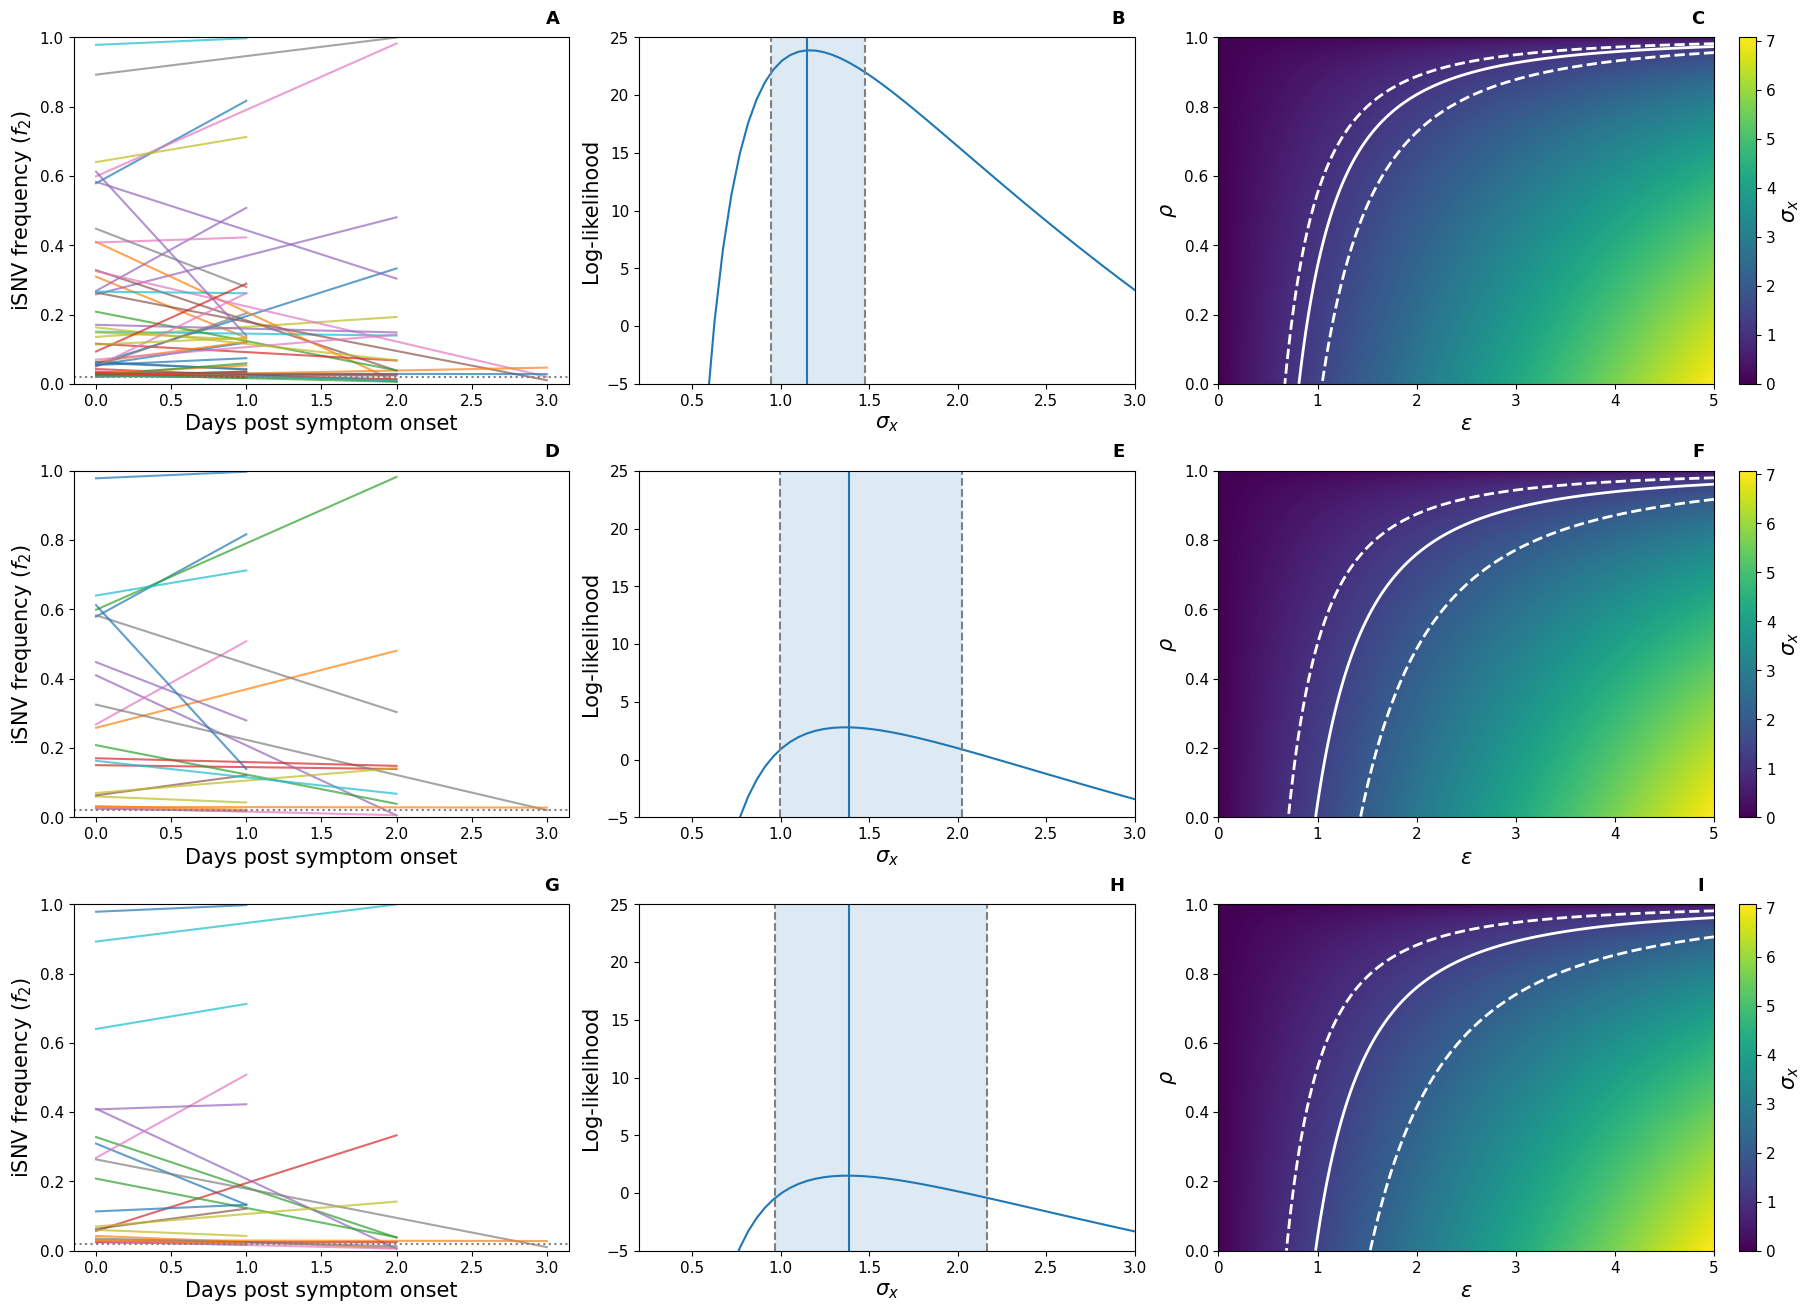

set_2
MLE sigma_x = 1.386441
Max log-likelihood = 1.502786
95% LR CI = [0.970781, 2.165316]

FULL
MLE sigma_x = 1.149153
Max log-likelihood = 23.880147
95% LR CI = [0.948326, 1.479084]

set_1
MLE sigma_x = 1.386441
Max log-likelihood = 2.788188
95% LR CI = [0.999002, 2.026974]


In [21]:
LOD = 0.02

# --- Prepare the two datasets ---
df = ton_filtered.copy()
for col in ["DPS1", "DPS2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["X0"] = df["DPS1 Frequency"].map(logit_transform)
df["XT"] = df["DPS2 Frequency"].map(logit_transform)
df["T"] = (df["DPS2"] - df["DPS1"])
df = df.dropna(subset=["DPS1", "DPS2"]).copy()

# Full dataset
ton_f = df.copy()

# --- Subset 2 for all three rows ---
full_df2  = prepare_subset(ton_f, LOD, logit_transform, subset_type=2, random_state=43)
#full_df2.to_csv("ton_full_subset2.csv", index=False)
full_df1  = prepare_subset(ton_f, LOD, logit_transform, subset_type=1, random_state=46)
#full_df1.to_csv("ton_full_subset1.csv", index=False)

# --- Sigma grid and profiles ---
sigma_grid = np.linspace(0.2, 3.0, 60)

full  = compute_sigma_profile(ton_f, sigma_grid, f_lower=0.02, f_upper=0.98)
set_1 = compute_sigma_profile(full_df1, sigma_grid, f_lower=0.02, f_upper=0.98)
set_2  = compute_sigma_profile(full_df2, sigma_grid, f_lower=0.02, f_upper=0.98)

# --- Heatmap contour targets ---
# Replace full_targets with the values for the full dataset row
full_targets  = sorted([full["sigma_mle"], full["ci_high"], full["ci_low"]])
subset1_targets  = sorted([set_1["sigma_mle"], set_1["ci_high"], set_1["ci_low"]])
subset2_targets = sorted([set_2["sigma_mle"], set_2["ci_high"], set_2["ci_low"]])

# --- 3 x 3 figure ---
fig, axes = plt.subplots(3, 3, figsize=(18, 13), constrained_layout=True)

# Row 1: full
plot_segments(axes[0, 0], ton_f, "A", xlabel="Days post symptom onset")
plot_ll_panel(axes[0, 1], sigma_grid, full, "B")
plot_heatmap_panel(axes[0, 2], fig, full_targets, "C")

plot_segments(axes[1, 0], full_df1, "D", xlabel="Days post symptom onset")
plot_ll_panel(axes[1, 1], sigma_grid, set_1, "E")
plot_heatmap_panel(axes[1, 2], fig, subset1_targets, "F")

plot_segments(axes[2, 0], full_df2, "G", xlabel="Days post symptom onset")
plot_ll_panel(axes[2, 1], sigma_grid, set_2, "H")
plot_heatmap_panel(axes[2, 2], fig, subset2_targets, "I")

# Match likelihood axis ranges
for ax in [axes[0, 1], axes[1, 1], axes[2, 1]]:
    ax.set_xlim(0.2, 3)
    ax.set_ylim(-5, 25)

plt.show()

print("set_2")
print(f"MLE sigma_x = {set_2['sigma_mle']:.6f}")
print(f"Max log-likelihood = {set_2['ll_mle']:.6f}")
print(f"95% LR CI = [{set_2['ci_low']:.6f}, {set_2['ci_high']:.6f}]")

print("\nFULL")
print(f"MLE sigma_x = {full['sigma_mle']:.6f}")
print(f"Max log-likelihood = {full['ll_mle']:.6f}")
print(f"95% LR CI = [{full['ci_low']:.6f}, {full['ci_high']:.6f}]")

print("\nset_1")
print(f"MLE sigma_x = {set_1['sigma_mle']:.6f}")
print(f"Max log-likelihood = {set_1['ll_mle']:.6f}")
print(f"95% LR CI = [{set_1['ci_low']:.6f}, {set_1['ci_high']:.6f}]")


### Swine-Table_S3

In [23]:
vaninsberghe = pd.read_csv("data/raw_data/table_S3.csv")
filtered_vaninsberghe = vaninsberghe[vaninsberghe["Subset"] == 1]


Table_S3 = filtered_vaninsberghe.rename(columns={
    "DPS1": "First sample (in days post symptom onset)",
    "DPS2": "Second sample (in days post symptom onset)",
    "DPS1 Frequency": "First sample iSNV frequency",
    "DPS2 Frequency": "Second sample iSNV frequency"
}).drop(columns=["Subset"])

In [24]:
Table_S3.to_csv("data/Table_S3.csv", index=False)

### Simulated noise free mock dataset

In [25]:
def simulate_isnv_frequency_init(
    t,
    f2_0=0.15,
    epsilon=0.2,
    rho=0.1,
    seed=None,
    return_X=False,
    init_dist="exponential",
    variant_call_threshold=0.02,
    max_resample=100000,
):
    """
    (A) Simulated iSNV frequency dynamics using:
        dX(t) = sigma_X dB(t),
    where X(t) = log(V2/V1), and
        sigma_X = epsilon * sqrt(2 * (1 - rho)).

    Frequency is mapped by the logistic transform:
        f2(t) = 1 / (1 + exp(-X(t))).

    Initialization:
        If init_dist == "exponential", draw initial f2(0) from an exponential
        distribution with mean = f2_0, then discard/resample until
        f2(0) >= variant_call_threshold and f2(0) < 1.
        If init_dist is None or "fixed", use f2_0 directly (still thresholded).

    Parameters
    ----------
    t : array-like
        Monotone increasing time points.
    f2_0 : float
        If init_dist="exponential": mean of the exponential for initial frequency.
        If init_dist="fixed"/None: fixed initial frequency.
        Default 0.15.
    epsilon : float
        Noise strength (default 0.2).
    rho : float
        Correlation (default 0.1).
    seed : int or None
        RNG seed.
    return_X : bool
        If True, also return X(t).
    init_dist : {"exponential","fixed",None}
        How to generate the initial frequency.
    variant_call_threshold : float
        Variant calling threshold (default 0.02 = 2%).
    max_resample : int
        Safety cap for resampling attempts.

    Returns
    -------
    f2 : np.ndarray, shape (len(t),)
        Simulated frequency trajectory.
    X : np.ndarray, shape (len(t),) (only if return_X=True)
        Simulated log-ratio trajectory.
    """
    t = np.asarray(t, dtype=float)
    if t.size < 2:
        raise ValueError("t must contain at least two time points.")
    if np.any(np.diff(t) <= 0):
        raise ValueError("t must be strictly increasing.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if epsilon < 0:
        raise ValueError("epsilon must be nonnegative.")
    if not (0.0 < variant_call_threshold < 1.0):
        raise ValueError("variant_call_threshold must be in (0, 1).")

    rng = np.random.default_rng(seed)
    def draw_initial_frequency():
        if init_dist in (None, "fixed"):
            return float(f2_0)
        if init_dist == "exponential":
            if f2_0 <= 0:
                raise ValueError("For init_dist='exponential', f2_0 (mean) must be > 0.")
            # numpy exponential uses 'scale' = mean
            return float(rng.exponential(scale=f2_0))
        raise ValueError("init_dist must be one of {'exponential','fixed',None}.")

    # Draw + discard/resample until above threshold and < 1
    f2_init = draw_initial_frequency()
    tries = 0
    while not (variant_call_threshold <= f2_init < 1.0):
        tries += 1
        if tries >= max_resample:
            raise RuntimeError(
                "Exceeded max_resample while drawing initial frequency. "
                "Consider increasing max_resample or adjusting f2_0 / variant_call_threshold."
            )
        f2_init = draw_initial_frequency()

    # Convert initial frequency to initial log-odds: X0 = log(f/(1-f))
    X0 = np.log(f2_init / (1.0 - f2_init))

    sigma_X = epsilon * np.sqrt(2.0 * (1.0 - rho))

    n = t.size
    X = np.empty(n, dtype=float)
    X[0] = X0

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        dB = rng.normal(loc=0.0, scale=np.sqrt(dt))  # N(0, dt)
        X[k + 1] = X[k] + sigma_X * dB

    f2 = 1.0 / (1.0 + np.exp(-X))

    if return_X:
        return f2, X
    return f2


def sample_initial_final(dataset, t, T, atol_time=1e-8):
    """
    Extract (f2(t=0), f2(t=T)) for every trajectory in `dataset`.

    Parameters
    ----------
    dataset : np.ndarray, shape (n_traj, n_time)
        Simulated trajectories where columns correspond to times in `t`.
    t : array-like, shape (n_time,)
        Monotone increasing time grid used to generate `dataset`.
    T : float
        Time (same units as `t`) at which to take the final sample.
    atol_time : float
        Maximum absolute time difference tolerated when matching T to available t.

    Returns
    -------
    samples : np.ndarray, shape (n_traj, 2)
        Column 0 = f2(t=0), Column 1 = f2(t=T).
        Returns None if T is outside the range [t.min(), t.max()].
    """
    t = np.asarray(t, dtype=float)
    if dataset.ndim != 2:
        raise ValueError("dataset must be 2D array: (n_traj, n_time).")
    n_traj, n_time = dataset.shape
    if n_time != t.size:
        raise ValueError("dataset number of timepoints does not match length of t.")
    t0 = t[0]
    if abs(t0) > atol_time:
        # still allow nonzero start but warn
        print(f"Warning: t[0] = {t0} (not exactly 0). initial sample uses t[0].")

    if not (t.min() - atol_time <= T <= t.max() + atol_time):
        print(f"Requested T={T} is outside simulated time range [{t.min()}, {t.max()}].")
        return None

    # find nearest index for T
    idx_T = int(np.argmin(np.abs(t - T)))
    if abs(t[idx_T] - T) > max(atol_time, 1e-6):
        # If the nearest time is still far, warn (but we allow small rounding)
        print(
            f"Note: nearest available time to requested T={T} is t[{idx_T}]={t[idx_T]} "
            f"(diff={t[idx_T]-T})."
        )

    # initial column: column 0 (t[0]). final column: idx_T
    samples = np.empty((n_traj, 2), dtype=float)
    samples[:, 0] = dataset[:, 0]
    samples[:, 1] = dataset[:, idx_T]
    return samples


def generate_dataset(
    t,
    epsilon,
    rho,
    n_traj=500,
    base_seed=1234,
    f2_mean=0.15,
):
    """
    Generate n_traj independent trajectories for given (epsilon, rho).
    Returns array of shape (n_traj, len(t)).
    """
    n_time = len(t)
    data = np.empty((n_traj, n_time))

    for i in range(n_traj):
        seed_i = base_seed + i  # independent but reproducible
        traj = simulate_isnv_frequency_init(
            t=t,
            f2_0=f2_mean,
            epsilon=epsilon,
            rho=rho,
            seed=seed_i,
            return_X=False,
            init_dist="exponential",
            variant_call_threshold=0.02,
        )
        data[i, :] = traj

    return data

def logit_transform(f, eps=1e-12):
    f = np.clip(f, eps, 1 - eps)
    return np.log(f / (1.0 - f))


def _normal_logpdf(x, mean, var):
    # log N(x; mean, var)
    return -0.5 * (math.log(2.0 * math.pi * var) + ((x - mean) ** 2) / var)


def bm_loglik_sigma_x_censored(
    X_pairs, T, sigma_x,
    f_threshold=0.02,
    x_threshold=None
):
    """
    Brownian motion log-likelihood for sigma_x with left-censoring on XT.

    If XT is observed (>= x_threshold): use Normal PDF.
    If XT is censored (<  x_threshold): use Normal CDF P(XT < x_threshold | X0).

    Parameters
    ----------
    X_pairs : array, shape (n, 2)
        Column 0 = X0, Column 1 = XT (or the reported XT even if it's below threshold).
    T : float
    sigma_x : float > 0
    f_threshold : float
        Variant calling threshold in frequency space (default 0.02).
    x_threshold : float or None
        If provided, overrides f_threshold and is interpreted directly in X-space.
    """
    X_pairs = np.asarray(X_pairs, dtype=float)
    if X_pairs.ndim != 2 or X_pairs.shape[1] != 2:
        raise ValueError("X_pairs must have shape (n, 2).")
    if T <= 0:
        raise ValueError("T must be positive.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_threshold is None:
        if not (0.0 < f_threshold < 1.0):
            raise ValueError("f_threshold must be in (0,1).")
        x_threshold = float(logit_transform(f_threshold))

    X0 = X_pairs[:, 0]
    XT = X_pairs[:, 1]

    var = (sigma_x ** 2) * T
    sd = sigma_x * math.sqrt(T)



    lower = x_threshold
    upper = x_threshold
    if not (lower < upper):
        raise ValueError("Need x_threshold < 0.5 for three-interval censoring.")

    # Censoring rule: if the second value is below X-threshold, treat as left-censored
    left_cens  = XT < lower
    right_cens = XT > upper
    mid_uncens = (~left_cens) & (~right_cens)

    loglik = 0.0

    if np.any(mid_uncens):
        for x0, xt in zip(X0[mid_uncens], XT[mid_uncens]):
            loglik += _normal_logpdf(xt, mean=x0, var=var)

    if np.any(left_cens):
        zL = (lower - X0[left_cens]) / sd
        loglik += np.sum(norm.logcdf(zL))

    if np.any(right_cens):
        zU = (upper - X0[right_cens]) / sd
        loglik += np.sum(norm.logsf(zU))

    return float(loglik)



In [29]:
t_start = 0.0
t_end   = 10.0
dt      = 0.001
t       = np.arange(t_start, t_end + dt, dt)

dataset_sigma_10_small = generate_dataset(
    t,
    epsilon=1,
    rho=0.5,
    n_traj=50,
    base_seed=100,
)

dataset_sigma_06_small = generate_dataset(
    t,
    epsilon=0.6,
    rho=0.5,
    n_traj=50,
    base_seed=200,
)

dataset_sigma_14_small = generate_dataset(
    t,
    epsilon=1.4,
    rho=0.5,
    n_traj=50,
    base_seed=300,
)

mock_datasets = {
    "(rho=0.5, epsilon=1)": dataset_sigma_10_small,
    "(rho=0.5, epsilon=0.6)": dataset_sigma_06_small,
    "(rho=0.5, epsilon=1.4)": dataset_sigma_14_small,
}

print("Shapes:")
for k, v in mock_datasets.items():
    print(k, v.shape)

Shapes:
(rho=0.5, epsilon=1) (50, 10001)
(rho=0.5, epsilon=0.6) (50, 10001)
(rho=0.5, epsilon=1.4) (50, 10001)


In [28]:

np.save("data/mock_datasets_sigma_06_small.npy", dataset_sigma_06_small)
np.save("data/mock_datasets_sigma_10_small.npy", dataset_sigma_10_small)
np.save("data/mock_datasets_sigma_14_small.npy", dataset_sigma_14_small)

In [30]:
T_list_hours = [24.0, 48.0, 96]
T_list_days = [T / 24.0 for T in T_list_hours]

# containers
f2_samples_all = {}

source_map = {
    "sigma_10": ("(rho=0.5, epsilon=1.0)", "dataset_sigma_10_small"),
    "sigma_06": ("(rho=0.5, epsilon=0.6)", "dataset_sigma_06_small"),
    "sigma_14": ("(rho=0.5, epsilon=1.4)", "dataset_sigma_14_small"),
}

for short, (label, varname) in source_map.items():
    dataset = globals().get(varname, None)
    if dataset is None:
        raise RuntimeError(f"Dataset variable '{varname}' not found.")

    f2_samples_all[short] = {}

    for T_hours, T_days in zip(T_list_hours, T_list_days):

        samples = sample_initial_final(
            dataset=dataset,
            t=t,
            T=T_days,   # now in days
        )

        # variable name still labeled in hours for clarity
        var_label = f"sample_{int(T_hours)}_{short}"
        f2_samples_all[short][int(T_hours)] = samples

        # also create explicit variable
        globals()[var_label] = samples

# Print summary
for short in f2_samples_all:
    for T in T_list_hours:
        arr = f2_samples_all[short][int(T)]
        if arr is None:
            print(f"{short} T={int(T)}h: NOT AVAILABLE")
        else:
            print(f"{short} T={int(T)}h: shape={arr.shape}, first_row={arr[0]}")

sigma_10 T=24h: shape=(50, 2), first_row=[0.18943306 0.50376751]
sigma_10 T=48h: shape=(50, 2), first_row=[0.18943306 0.56756921]
sigma_10 T=96h: shape=(50, 2), first_row=[0.18943306 0.80596324]
sigma_06 T=24h: shape=(50, 2), first_row=[0.11296195 0.06457906]
sigma_06 T=48h: shape=(50, 2), first_row=[0.11296195 0.06951355]
sigma_06 T=96h: shape=(50, 2), first_row=[0.11296195 0.08816   ]
sigma_14 T=24h: shape=(50, 2), first_row=[0.13363389 0.10833755]
sigma_14 T=48h: shape=(50, 2), first_row=[0.13363389 0.11219277]
sigma_14 T=96h: shape=(50, 2), first_row=[0.13363389 0.30204839]


In [31]:
X_samples_all = {}

for short in f2_samples_all:
    X_samples_all[short] = {}

    for T in f2_samples_all[short]:
        f2_array = f2_samples_all[short][T]   # shape (500, 2)

        if f2_array is None:
            X_samples_all[short][T] = None
            continue

        # Apply logit transform columnwise
        X_array = logit_transform(f2_array)

        X_samples_all[short][T] = X_array

        globals()[f"X_sample_{T}_{short}"] = X_array

for short in X_samples_all:
    for T in X_samples_all[short]:
        arr = X_samples_all[short][T]
        if arr is not None:
            print(f"X_sample_{T}_{short}: shape={arr.shape}, first_row={arr[0]}")

X_sample_24_sigma_10: shape=(50, 2), first_row=[-1.45369823  0.01507034]
X_sample_48_sigma_10: shape=(50, 2), first_row=[-1.45369823  0.27194041]
X_sample_96_sigma_10: shape=(50, 2), first_row=[-1.45369823  1.42399054]
X_sample_24_sigma_06: shape=(50, 2), first_row=[-2.06083688 -2.67310644]
X_sample_48_sigma_06: shape=(50, 2), first_row=[-2.06083688 -2.59418578]
X_sample_96_sigma_06: shape=(50, 2), first_row=[-2.06083688 -2.33631121]
X_sample_24_sigma_14: shape=(50, 2), first_row=[-1.86920367 -2.1078358 ]
X_sample_48_sigma_14: shape=(50, 2), first_row=[-1.86920367 -2.06853613]
X_sample_96_sigma_14: shape=(50, 2), first_row=[-1.86920367 -0.83756253]


In [32]:
np.save("data/X_samples_all.npy", X_samples_all)

#### Simulation noise free evaluation dataset

In [53]:
cut = -0.5 * 3.841458820694124  # ~= -1.9207294103
dataset_sigma_15 = generate_dataset(
    t,
    epsilon=1.5,
    rho=0.5,
    n_traj=50,
    base_seed=1000,
)

dataset_sigma_25 = generate_dataset(
    t,
    epsilon=2.5,
    rho=0.5,
    n_traj=50,
    base_seed=2000,
)

dataset_sigma_35 = generate_dataset(
    t,
    epsilon=3.5,
    rho=0.5,
    n_traj=50,
    base_seed=3000,
)

sigma_map = {
    "sigma_15": 1.5,
    "sigma_25": 2.5,
    "sigma_35": 3.5,
}

T_hours_list = [1, 6, 12, 24, 48, 72]
T_days_map = {h: h / 24.0 for h in T_hours_list}

source_map = {
    "sigma_15": dataset_sigma_15,
    "sigma_25": dataset_sigma_25,
    "sigma_35": dataset_sigma_35,
}

f2_samples_all = {}

for short, dataset in source_map.items():

    f2_samples_all[short] = {}

    for T_hours in T_hours_list:

        T_days = T_days_map[T_hours]

        samples = sample_initial_final(
            dataset=dataset,
            t=t,
            T=T_days,   # T in days
        )

        f2_samples_all[short][T_hours] = samples


X_samples_all = {}

for short in f2_samples_all:
    X_samples_all[short] = {}

    for T in f2_samples_all[short]:
        f2_array = f2_samples_all[short][T]   # shape (500, 2)

        if f2_array is None:
            X_samples_all[short][T] = None
            continue

        # Apply logit transform columnwise
        X_array = logit_transform(f2_array)

        X_samples_all[short][T] = X_array

        # Optional: create convenient variable names like X_sample_6_sigma_04
        globals()[f"X_sample_{T}_{short}"] = X_array

for short in X_samples_all:
    for T in X_samples_all[short]:
        arr = X_samples_all[short][T]
        if arr is not None:
            print(f"X_sample_{T}_{short}: shape={arr.shape}, first_row={arr[0]}")

X_sample_1_sigma_15: shape=(50, 2), first_row=[-1.43057251 -1.18740955]
X_sample_6_sigma_15: shape=(50, 2), first_row=[-1.43057251 -0.70056207]
X_sample_12_sigma_15: shape=(50, 2), first_row=[-1.43057251 -0.94523466]
X_sample_24_sigma_15: shape=(50, 2), first_row=[-1.43057251 -1.94357178]
X_sample_48_sigma_15: shape=(50, 2), first_row=[-1.43057251 -1.65841495]
X_sample_72_sigma_15: shape=(50, 2), first_row=[-1.43057251 -1.98500834]
X_sample_1_sigma_25: shape=(50, 2), first_row=[-2.13153497 -1.04419756]
X_sample_6_sigma_25: shape=(50, 2), first_row=[-2.13153497 -2.12265591]
X_sample_12_sigma_25: shape=(50, 2), first_row=[-2.13153497 -2.73276194]
X_sample_24_sigma_25: shape=(50, 2), first_row=[-2.13153497 -5.1828034 ]
X_sample_48_sigma_25: shape=(50, 2), first_row=[-2.13153497 -0.85660516]
X_sample_72_sigma_25: shape=(50, 2), first_row=[-2.13153497 -4.71621841]
X_sample_1_sigma_35: shape=(50, 2), first_row=[-1.5037718  -1.55146306]
X_sample_6_sigma_35: shape=(50, 2), first_row=[-1.503771

In [55]:
# --------------------------------------------------
# 1) Build a tidy dataframe from your simulated data
# --------------------------------------------------
def build_simulation_dataframe(X_samples_all, sigma_map, T_hours_list, T_days_map):
    rows = []

    for short, sigma in sigma_map.items():
        for T_hours in T_hours_list:
            T_days = float(T_days_map[T_hours])
            X_pairs = np.asarray(X_samples_all[short][T_hours], dtype=float)

            X0 = X_pairs[:, 0]
            XT = X_pairs[:, 1]
            dX = XT - X0
            abs_dX = np.abs(dX)

            for i in range(len(X_pairs)):
                rows.append({
                    "sigma_key": short,
                    "sigma": float(sigma),
                    "sample_id": int(i),
                    "T_hours": float(T_hours),
                    "T_days": T_days,
                    "X0": float(X0[i]),
                    "XT": float(XT[i]),
                    "dX": float(dX[i]),
                    "abs_dX": float(abs_dX[i]),
                })

    return pd.DataFrame(rows)

sigma_map = {
    "sigma_15": 1.5,
    "sigma_25": 2.5,
    "sigma_35": 3.5,
}

# --------------------------------------------------
# 2) Save dataset so it can be reloaded later
# --------------------------------------------------
df_sim = build_simulation_dataframe(
    X_samples_all=X_samples_all,
    sigma_map=sigma_map,
    T_hours_list=T_hours_list,
    T_days_map=T_days_map,
)

# Best option if available
try:
    df_sim.to_parquet("data/simulated_brownian_data.parquet", index=False)
    print("Saved: simulated_brownian_data.parquet")
except Exception:
    # Safe fallback
    df_sim.to_csv("data/simulated_brownian_data.csv", index=False)
    print("Saved: simulated_brownian_data.csv")



Saved: simulated_brownian_data.csv


### Simulated with measurement noise mock dataset

In [33]:

# ======================================================================
# Data generation
# ======================================================================

def simulate_isnv_frequency_init(
    t,
    f2_0=0.15,
    epsilon=0.2,
    rho=0.1,
    seed=None,
    return_X=False,
    init_dist="exponential",
    variant_call_threshold=0.02,
    max_resample=100000,
):
    """
    Simulated iSNV frequency dynamics using dX(t) = sigma_X dB(t),
    with sigma_X = epsilon * sqrt(2 * (1 - rho)) and f2 = logistic(X).

    NOTE: the resampling here bounds only the *true* initial frequency, and
    only from below (>= variant_call_threshold). It is NOT the observed-initial
    filter; that is applied after measurement noise (see keep_initial_in_range).

    The Brownian increments are drawn in one batch; numpy's Generator produces
    the identical stream as the previous per-step scalar draws, so trajectories
    are bit-for-bit unchanged for a given seed (just much faster, which matters
    now that we oversample).
    """
    t = np.asarray(t, dtype=float)
    if t.size < 2:
        raise ValueError("t must contain at least two time points.")
    if np.any(np.diff(t) <= 0):
        raise ValueError("t must be strictly increasing.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if epsilon < 0:
        raise ValueError("epsilon must be nonnegative.")
    if not (0.0 < variant_call_threshold < 1.0):
        raise ValueError("variant_call_threshold must be in (0, 1).")

    rng = np.random.default_rng(seed)

    def draw_initial_frequency():
        if init_dist in (None, "fixed"):
            return float(f2_0)
        if init_dist == "exponential":
            if f2_0 <= 0:
                raise ValueError("For init_dist='exponential', f2_0 (mean) must be > 0.")
            return float(rng.exponential(scale=f2_0))
        raise ValueError("init_dist must be one of {'exponential','fixed',None}.")

    f2_init = draw_initial_frequency()
    tries = 0
    while not (variant_call_threshold <= f2_init < 1.0):
        tries += 1
        if tries >= max_resample:
            raise RuntimeError("Exceeded max_resample while drawing initial frequency.")
        f2_init = draw_initial_frequency()

    X0 = np.log(f2_init / (1.0 - f2_init))
    sigma_X = epsilon * np.sqrt(2.0 * (1.0 - rho))

    dt = np.diff(t)
    dB = rng.standard_normal(dt.size) * np.sqrt(dt)
    X = np.empty(t.size, dtype=float)
    X[0] = X0
    X[1:] = X0 + sigma_X * np.cumsum(dB)

    f2 = 1.0 / (1.0 + np.exp(-X))
    if return_X:
        return f2, X
    return f2


def generate_dataset(t, epsilon, rho, n_traj=500, base_seed=42, f2_mean=0.15):
    n_time = len(t)
    data = np.empty((n_traj, n_time))
    for i in range(n_traj):
        seed_i = base_seed + i
        data[i, :] = simulate_isnv_frequency_init(
            t=t, f2_0=f2_mean, epsilon=epsilon, rho=rho, seed=seed_i,
            return_X=False, init_dist="exponential", variant_call_threshold=0.02,
        )
    return data


def sample_initial_final(dataset, t, T, atol_time=1e-8):
    t = np.asarray(t, dtype=float)
    if dataset.ndim != 2:
        raise ValueError("dataset must be 2D array: (n_traj, n_time).")
    n_traj, n_time = dataset.shape
    if n_time != t.size:
        raise ValueError("dataset number of timepoints does not match length of t.")
    if not (t.min() - atol_time <= T <= t.max() + atol_time):
        print(f"Requested T={T} is outside simulated time range [{t.min()}, {t.max()}].")
        return None
    idx_T = int(np.argmin(np.abs(t - T)))
    samples = np.empty((n_traj, 2), dtype=float)
    samples[:, 0] = dataset[:, 0]
    samples[:, 1] = dataset[:, idx_T]
    return samples


def add_beta_measurement_noise(dataset, nu_measnoise=1.0, seed=None, eps=1e-12):
    """f_obs ~ Beta(mu*nu, (1-mu)*nu), applied to every timepoint (untruncated)."""
    dataset = np.asarray(dataset, dtype=float)
    if nu_measnoise <= 0:
        raise ValueError("nu_measnoise must be positive.")
    rng = np.random.default_rng(seed)
    mu = np.clip(dataset, eps, 1.0 - eps)
    return rng.beta(mu * nu_measnoise, (1.0 - mu) * nu_measnoise)


# ======================================================================
# Observed-initial filter
# ======================================================================
# The measurement process draws an *untruncated* beta and we then discard
# trajectories whose OBSERVED initial frequency falls outside the calling
# range. This is a filter on the support of the data, NOT a truncated emission
# density -- so the inference below uses the plain (untruncated) beta.
#
# Note the filter depends only on column 0 of the noisy dataset, which is the
# same for every T. So we can select the surviving trajectories ONCE and reuse
# the identical 50 trajectories at every T (better for cross-T comparison).

def keep_initial_in_range(samples, lower=0.05, upper=0.95):
    """Keep only pairs whose observed initial frequency (col 0) is in [lower, upper]."""
    if samples is None:
        return None
    keep = (samples[:, 0] >= lower) & (samples[:, 0] <= upper)
    return samples[keep]


def select_calibrated_trajectories(noisy_dataset, lower=0.05, upper=0.95, n_keep=50,
                                   label=""):
    """
    Oversampled -> filtered -> trimmed to exactly n_keep trajectories.

    Returns (dataset_kept, idx_kept). Raises if fewer than n_keep survive, with a
    message telling you how much to oversample.
    """
    q0_obs = noisy_dataset[:, 0]
    idx = np.flatnonzero((q0_obs >= lower) & (q0_obs <= upper))
    n_gen = noisy_dataset.shape[0]
    if idx.size < n_keep:
        rate = idx.size / n_gen
        need = int(math.ceil(n_keep / max(rate, 1e-9) * 1.2))
        raise RuntimeError(
            f"{label}: only {idx.size}/{n_gen} trajectories passed the initial filter "
            f"(rate {rate:.2f}); need {n_keep}. Increase N_TRAJ_GEN to about {need}."
        )
    n_pass = idx.size
    idx = idx[:n_keep]                      # keep the first n_keep survivors
    print(f"{label}: {n_pass}/{n_gen} passed the initial filter "
          f"(rate {n_pass / n_gen:.2f}); using the first {n_keep}.")
    return noisy_dataset[idx], idx


# ======================================================================
# Build datasets, add noise, select exactly N_KEEP survivors, then pair up
# ======================================================================

t_start, t_end, dt = 0.0, 10.0, 0.001
t = np.arange(t_start, t_end + dt, dt)

N_KEEP = 50        # number of mock pairs we actually want to fit
N_TRAJ_GEN = 200   # oversample: ~55-65% survive the initial filter at nu = 10

dataset_sigma_06_small = generate_dataset(t, epsilon=0.6, rho=0.5, n_traj=N_TRAJ_GEN, base_seed=200)
dataset_sigma_10_small = generate_dataset(t, epsilon=1.0, rho=0.5, n_traj=N_TRAJ_GEN, base_seed=100)
dataset_sigma_14_small = generate_dataset(t, epsilon=1.4, rho=0.5, n_traj=N_TRAJ_GEN, base_seed=300)

nu_measnoise = 10  # true measurement concentration used to build the mock data

dataset_sigma_06_measnoise = add_beta_measurement_noise(dataset_sigma_06_small, nu_measnoise, seed=1200)
dataset_sigma_10_measnoise = add_beta_measurement_noise(dataset_sigma_10_small, nu_measnoise, seed=1100)
dataset_sigma_14_measnoise = add_beta_measurement_noise(dataset_sigma_14_small, nu_measnoise, seed=1400)

datasets_map_measnoise = {
    "sigma_06": dataset_sigma_06_measnoise,
    "sigma_10": dataset_sigma_10_measnoise,
    "sigma_14": dataset_sigma_14_measnoise,
}

# calling range used to FILTER the observed initial
INIT_FILTER_LOWER = 0.05
INIT_FILTER_UPPER = 0.95
# threshold used to CENSOR the final observation inside the measurement model
FINAL_CENSOR_THRESHOLD = 0.02

T_hours_list = [24, 48, 96]
T_days_map = {h: h / 24.0 for h in T_hours_list}

datasets_kept = {}
X_samples_all_measnoise_40 = {}
for short, dataset in datasets_map_measnoise.items():
    kept, _ = select_calibrated_trajectories(
        dataset, INIT_FILTER_LOWER, INIT_FILTER_UPPER, N_KEEP, label=short
    )
    datasets_kept[short] = kept
    X_samples_all_measnoise_40[short] = {}
    for T_hours in T_hours_list:
        samples = sample_initial_final(dataset=kept, t=t, T=T_days_map[T_hours])
        X_samples_all_measnoise_40[short][T_hours] = None if samples is None else logit_transform(samples)


sigma_06: 144/200 passed the initial filter (rate 0.72); using the first 50.
sigma_10: 136/200 passed the initial filter (rate 0.68); using the first 50.
sigma_14: 139/200 passed the initial filter (rate 0.69); using the first 50.


In [34]:
# ---- nu = 400 noisy datasets ----
NU_400 = 400

dataset_sigma_06_nu400 = add_beta_measurement_noise(dataset_sigma_06_small, NU_400, seed=1200)
dataset_sigma_10_nu400 = add_beta_measurement_noise(dataset_sigma_10_small, NU_400, seed=1200)
dataset_sigma_14_nu400 = add_beta_measurement_noise(dataset_sigma_14_small, NU_400, seed=1200)

# Filter: observed initial must lie in [INIT_FILTER_LOWER, INIT_FILTER_UPPER]
kept_06_nu400, _ = select_calibrated_trajectories(
    dataset_sigma_06_nu400, INIT_FILTER_LOWER, INIT_FILTER_UPPER, N_KEEP, "sigma_06_nu400")
kept_10_nu400, _ = select_calibrated_trajectories(
    dataset_sigma_10_nu400, INIT_FILTER_LOWER, INIT_FILTER_UPPER, N_KEEP, "sigma_10_nu400")
kept_14_nu400, _ = select_calibrated_trajectories(
    dataset_sigma_14_nu400, INIT_FILTER_LOWER, INIT_FILTER_UPPER, N_KEEP, "sigma_14_nu400")

# Logit-space pairs for inference
def _to_X_pairs(kept, t, T):
    return logit_transform(sample_initial_final(kept, t, T))

X_pairs_06_nu400 = _to_X_pairs(kept_06_nu400, t, T_days)
X_pairs_10_nu400 = _to_X_pairs(kept_10_nu400, t, T_days)
X_pairs_14_nu400 = _to_X_pairs(kept_14_nu400, t, T_days)

# nu = 10 logit-space pairs (already computed above via X_samples_all_measnoise)
X_pairs_06_nu10 = X_samples_all_measnoise_40["sigma_06"][24]
X_pairs_10_nu10 = X_samples_all_measnoise_40["sigma_10"][24]
X_pairs_14_nu10 = X_samples_all_measnoise_40["sigma_14"][24]

np.save("data/X_pairs_nu10.npy", {
    "sigma_06": X_pairs_06_nu10,
    "sigma_10": X_pairs_10_nu10,
    "sigma_14": X_pairs_14_nu10,
})

np.save("data/X_pairs_nu400.npy", {
    "sigma_06": X_pairs_06_nu400,
    "sigma_10": X_pairs_10_nu400,
    "sigma_14": X_pairs_14_nu400,
})


sigma_06_nu400: 171/200 passed the initial filter (rate 0.85); using the first 50.
sigma_10_nu400: 165/200 passed the initial filter (rate 0.82); using the first 50.
sigma_14_nu400: 172/200 passed the initial filter (rate 0.86); using the first 50.


In [36]:
np.save("data/dataset_sigma_06_nu400.npy", dataset_sigma_06_nu400)
np.save("data/dataset_sigma_10_nu400.npy", dataset_sigma_10_nu400)
np.save("data/dataset_sigma_14_nu400.npy", dataset_sigma_14_nu400)

np.save("data/dataset_sigma_06_nu40.npy", dataset_sigma_06_measnoise)
np.save("data/dataset_sigma_10_nu40.npy", dataset_sigma_10_measnoise)
np.save("data/dataset_sigma_14_nu40.npy", dataset_sigma_14_measnoise)
